# 🚢 Titanic Dataset — Exploratory Data Analysis
**Author:** Omkar | Aspiring GenAI Expert  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Titanic — 891 passengers, 12 features  

## Objective
To perform a complete EDA on the Titanic dataset and uncover
what factors determined survival on the night of April 15, 1912.

In [1]:
# ================================
# TITANIC DATASET — EXPLORATORY DATA ANALYSIS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style — makes all charts look clean and professional
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully
Shape: 891 rows × 12 columns


## Step 1 — Understanding the Data
Before touching any algorithm, we need to understand
what we're working with.  
**Why this matters:** You can't analyse what you don't understand.

In [2]:
# ================================
# STEP 1 — UNDERSTANDING THE DATA
# Before doing anything, we need to know what we're working with
# ================================

print("=" * 50)
print("BASIC INFORMATION")
print("=" * 50)

# Shape
print(f"\n📊 Dataset Shape: {df.shape[0]} passengers, {df.shape[1]} features")

# Column names and data types
print("\n📋 Columns & Data Types:")
print(df.dtypes)

# First 5 rows
print("\n👀 First 5 rows:")
print(df.head())

# Basic statistics
print("\n📈 Basic Statistics:")
print(df.describe().round(2))

BASIC INFORMATION

📊 Dataset Shape: 891 passengers, 12 features

📋 Columns & Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

👀 First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4 

## Step 2 — Missing Value Analysis
Real world data is always messy. Finding missing values
is the first cleaning step.  
**Why this matters:** ML models cannot handle missing values
they either crash or give wrong results.

MISSING VALUE ANALYSIS

🔍 Columns with missing values:
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


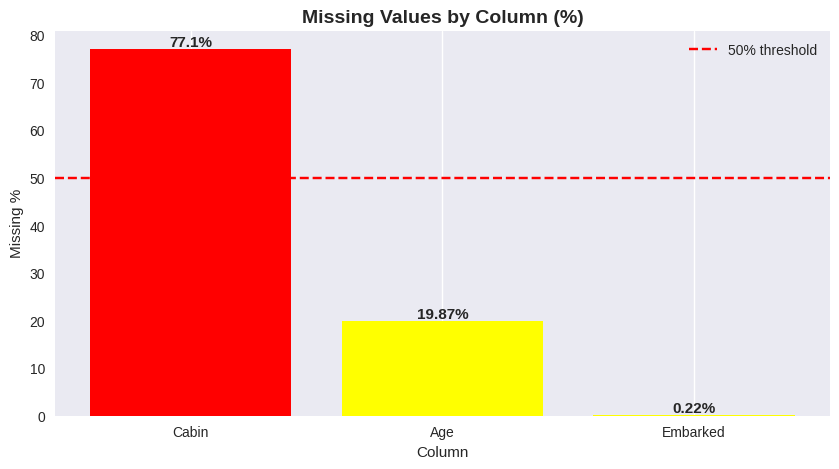


💡 Treatment Plan:
Cabin   → DROP (77% missing — too much to fill)
Age     → FILL with median (20% missing — salvageable)
Embarked→ FILL with mode (0.2% missing — just 2 rows)


In [3]:
# ================================
# STEP 2 — MISSING VALUE ANALYSIS
# Missing data breaks ML models — we must find and fix it
# ================================

print("=" * 50)
print("MISSING VALUE ANALYSIS")
print("=" * 50)

# Count missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df["Missing Count"] > 0]
print("\n🔍 Columns with missing values:")
print(missing_df)

# Visualize missing values
plt.figure(figsize=(10, 5))
plt.bar(missing_df.index,
        missing_df["Missing %"],
        color=["red" if x > 50 else "orange" if x > 20 else "yellow"
               for x in missing_df["Missing %"]])

for i, (col, val) in enumerate(missing_df["Missing %"].items()):
    plt.text(i, val + 0.5, f"{val}%", ha="center", fontsize=11, fontweight="bold")

plt.title("Missing Values by Column (%)", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.axhline(y=50, color="red", linestyle="--", label="50% threshold")
plt.legend()
plt.grid(axis="y")
plt.show()

# Decision for each column
print("\n💡 Treatment Plan:")
print("Cabin   → DROP (77% missing — too much to fill)")
print("Age     → FILL with median (20% missing — salvageable)")
print("Embarked→ FILL with mode (0.2% missing — just 2 rows)")

## Step 3 — Fixing Missing Values
Different columns need different treatment strategies.  
**Rules applied:**
- **>50% missing** → Drop the column entirely
- **Numerical + outliers** → Fill with Median
- **Categorical** → Fill with Mode
- **Very few missing** → Drop those rows

In [4]:
# ================================
# STEP 3 — FIXING MISSING VALUES
# Different strategies for different columns
# ================================

print("=" * 50)
print("BEFORE TREATMENT")
print("=" * 50)
print(df[["Age", "Cabin", "Embarked"]].isnull().sum())

# 1. DROP Cabin — 77% missing, not salvageable
df = df.drop(columns=["Cabin"])
print("\n✅ Cabin column dropped")

# 2. FILL Age with median — numerical with outliers
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print(f"✅ Age filled with median: {age_median}")

# 3. FILL Embarked with mode — categorical, only 2 missing
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)
print(f"✅ Embarked filled with mode: {embarked_mode}")

print("\n" + "=" * 50)
print("AFTER TREATMENT")
print("=" * 50)
print(df.isnull().sum())
print(f"\n✅ Total missing values remaining: {df.isnull().sum().sum()}")

BEFORE TREATMENT
Age         177
Cabin       687
Embarked      2
dtype: int64

✅ Cabin column dropped
✅ Age filled with median: 28.0
✅ Embarked filled with mode: S

AFTER TREATMENT
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

✅ Total missing values remaining: 0


## Step 4 — Distribution Analysis
Understanding how each numerical feature is spread.  
**Why this matters:** Skewed distributions and outliers
directly impact model performance.

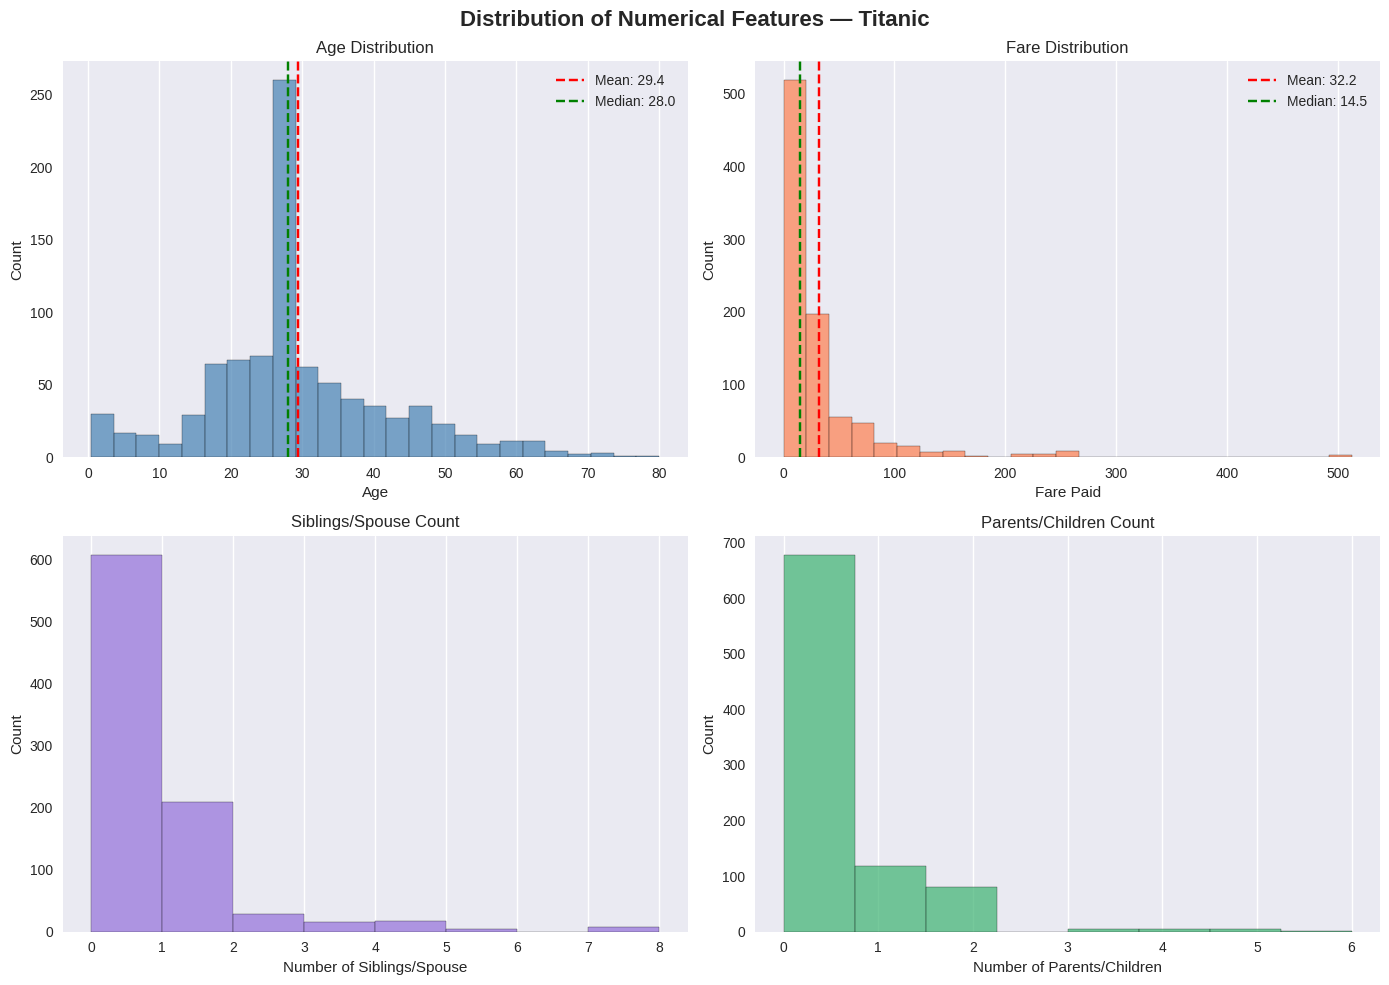

KEY OBSERVATIONS

📊 Age:
   Mean:   29.4 years
   Median: 28.0 years
   Std:    13.0 years
   Min:    0.4 | Max: 80.0

💰 Fare:
   Mean:   £32.2
   Median: £14.5
   Std:    £49.7
   Min:    £0.0 | Max: £512.3

👨‍👩‍👧 Most passengers travelled alone:
   No siblings/spouse: 608 passengers
   No parents/children: 678 passengers


In [5]:
# ================================
# STEP 4 — DISTRIBUTION ANALYSIS
# Understanding how each numerical feature is spread
# ================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Numerical Features — Titanic",
             fontsize=16, fontweight="bold")

# Chart 1 — Age distribution
axes[0, 0].hist(df["Age"], bins=25, color="steelblue",
                edgecolor="black", alpha=0.7)
axes[0, 0].axvline(df["Age"].mean(), color="red",
                   linestyle="--", label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].axvline(df["Age"].median(), color="green",
                   linestyle="--", label=f"Median: {df['Age'].median():.1f}")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()
axes[0, 0].grid(axis="y")

# Chart 2 — Fare distribution
axes[0, 1].hist(df["Fare"], bins=25, color="coral",
                edgecolor="black", alpha=0.7)
axes[0, 1].axvline(df["Fare"].mean(), color="red",
                   linestyle="--", label=f"Mean: {df['Fare'].mean():.1f}")
axes[0, 1].axvline(df["Fare"].median(), color="green",
                   linestyle="--", label=f"Median: {df['Fare'].median():.1f}")
axes[0, 1].set_title("Fare Distribution")
axes[0, 1].set_xlabel("Fare Paid")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()
axes[0, 1].grid(axis="y")

# Chart 3 — SibSp distribution
axes[1, 0].hist(df["SibSp"], bins=8, color="mediumpurple",
                edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Siblings/Spouse Count")
axes[1, 0].set_xlabel("Number of Siblings/Spouse")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(axis="y")

# Chart 4 — Parch distribution
axes[1, 1].hist(df["Parch"], bins=8, color="mediumseagreen",
                edgecolor="black", alpha=0.7)
axes[1, 1].set_title("Parents/Children Count")
axes[1, 1].set_xlabel("Number of Parents/Children")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(axis="y")

plt.tight_layout()
plt.show()

# Print key observations
print("=" * 50)
print("KEY OBSERVATIONS")
print("=" * 50)
print(f"\n📊 Age:")
print(f"   Mean:   {df['Age'].mean():.1f} years")
print(f"   Median: {df['Age'].median():.1f} years")
print(f"   Std:    {df['Age'].std():.1f} years")
print(f"   Min:    {df['Age'].min():.1f} | Max: {df['Age'].max():.1f}")

print(f"\n💰 Fare:")
print(f"   Mean:   £{df['Fare'].mean():.1f}")
print(f"   Median: £{df['Fare'].median():.1f}")
print(f"   Std:    £{df['Fare'].std():.1f}")
print(f"   Min:    £{df['Fare'].min():.1f} | Max: £{df['Fare'].max():.1f}")

print(f"\n👨‍👩‍👧 Most passengers travelled alone:")
print(f"   No siblings/spouse: {(df['SibSp']==0).sum()} passengers")
print(f"   No parents/children: {(df['Parch']==0).sum()} passengers")

## Step 5 — Categorical Analysis
Understanding text features and their relationship with survival.  
**Why this matters:** Categorical features often carry the
strongest signals gender and class proved this here.

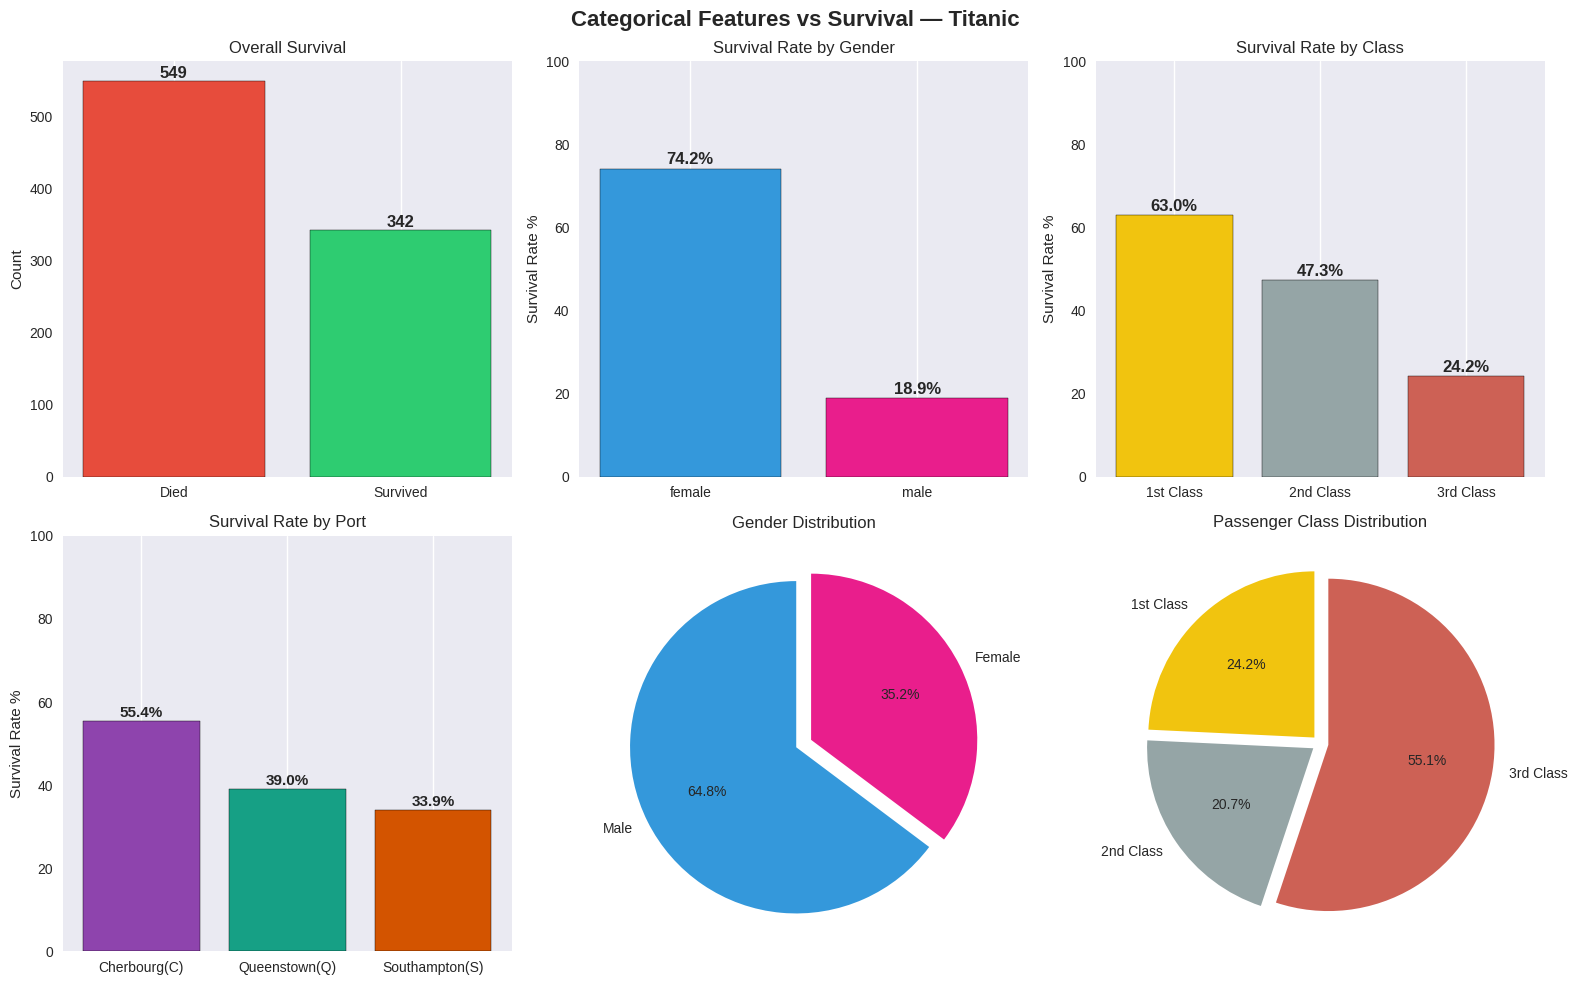

KEY OBSERVATIONS

👥 Gender:
   Female survival rate: 74.2%
   Male survival rate:   18.9%

🎫 Class:
   1st class survival: 63.0%
   2nd class survival: 47.3%
   3rd class survival: 24.2%

⚓ Port:
   Cherbourg survival:   55.4%
   Queenstown survival:  39.0%
   Southampton survival: 33.9%


In [6]:
# ================================
# STEP 5 — CATEGORICAL ANALYSIS
# Understanding text/category features
# and their relationship with survival
# ================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Categorical Features vs Survival — Titanic",
             fontsize=16, fontweight="bold")

# Chart 1 — Overall survival
survival_counts = df["Survived"].value_counts()
axes[0, 0].bar(["Died", "Survived"],
               survival_counts.values,
               color=["#E74C3C", "#2ECC71"],
               edgecolor="black")
for i, val in enumerate(survival_counts.values):
    axes[0, 0].text(i, val + 5, str(val),
                    ha="center", fontsize=12, fontweight="bold")
axes[0, 0].set_title("Overall Survival")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(axis="y")

# Chart 2 — Survival by Gender
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
axes[0, 1].bar(gender_survival.index,
               gender_survival.values,
               color=["#3498DB", "#E91E8C"],
               edgecolor="black")
for i, val in enumerate(gender_survival.values):
    axes[0, 1].text(i, val + 1, f"{val:.1f}%",
                    ha="center", fontsize=12, fontweight="bold")
axes[0, 1].set_title("Survival Rate by Gender")
axes[0, 1].set_ylabel("Survival Rate %")
axes[0, 1].set_ylim(0, 100)
axes[0, 1].grid(axis="y")

# Chart 3 — Survival by Class
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
axes[0, 2].bar(["1st Class", "2nd Class", "3rd Class"],
               class_survival.values,
               color=["#F1C40F", "#95A5A6", "#CD6155"],
               edgecolor="black")
for i, val in enumerate(class_survival.values):
    axes[0, 2].text(i, val + 1, f"{val:.1f}%",
                    ha="center", fontsize=12, fontweight="bold")
axes[0, 2].set_title("Survival Rate by Class")
axes[0, 2].set_ylabel("Survival Rate %")
axes[0, 2].set_ylim(0, 100)
axes[0, 2].grid(axis="y")

# Chart 4 — Survival by Embarked
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100
axes[1, 0].bar(["Cherbourg(C)", "Queenstown(Q)", "Southampton(S)"],
               embarked_survival.values,
               color=["#8E44AD", "#16A085", "#D35400"],
               edgecolor="black")
for i, val in enumerate(embarked_survival.values):
    axes[1, 0].text(i, val + 1, f"{val:.1f}%",
                    ha="center", fontsize=11, fontweight="bold")
axes[1, 0].set_title("Survival Rate by Port")
axes[1, 0].set_ylabel("Survival Rate %")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].grid(axis="y")

# Chart 5 — Gender breakdown
gender_counts = df["Sex"].value_counts()
axes[1, 1].pie(gender_counts.values,
               labels=["Male", "Female"],
               colors=["#3498DB", "#E91E8C"],
               autopct="%1.1f%%",
               startangle=90,
               explode=(0.05, 0.05))
axes[1, 1].set_title("Gender Distribution")

# Chart 6 — Class breakdown
class_counts = df["Pclass"].value_counts().sort_index()
axes[1, 2].pie(class_counts.values,
               labels=["1st Class", "2nd Class", "3rd Class"],
               colors=["#F1C40F", "#95A5A6", "#CD6155"],
               autopct="%1.1f%%",
               startangle=90,
               explode=(0.05, 0.05, 0.05))
axes[1, 2].set_title("Passenger Class Distribution")

plt.tight_layout()
plt.show()

# Print key numbers
print("=" * 50)
print("KEY OBSERVATIONS")
print("=" * 50)
print(f"\n👥 Gender:")
print(f"   Female survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"   Male survival rate:   {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")

print(f"\n🎫 Class:")
print(f"   1st class survival: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"   2nd class survival: {df[df['Pclass']==2]['Survived'].mean()*100:.1f}%")
print(f"   3rd class survival: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")

print(f"\n⚓ Port:")
print(f"   Cherbourg survival:   {df[df['Embarked']=='C']['Survived'].mean()*100:.1f}%")
print(f"   Queenstown survival:  {df[df['Embarked']=='Q']['Survived'].mean()*100:.1f}%")
print(f"   Southampton survival: {df[df['Embarked']=='S']['Survived'].mean()*100:.1f}%")

## Step 6 — Outlier Detection
Using box plots and the IQR method to find extreme values.  
**Why this matters:** Outliers skew model training  
but not all outliers should be removed.  
**Key rule:** Meaningful outliers carry signal. Data error
outliers carry noise. Know the difference.

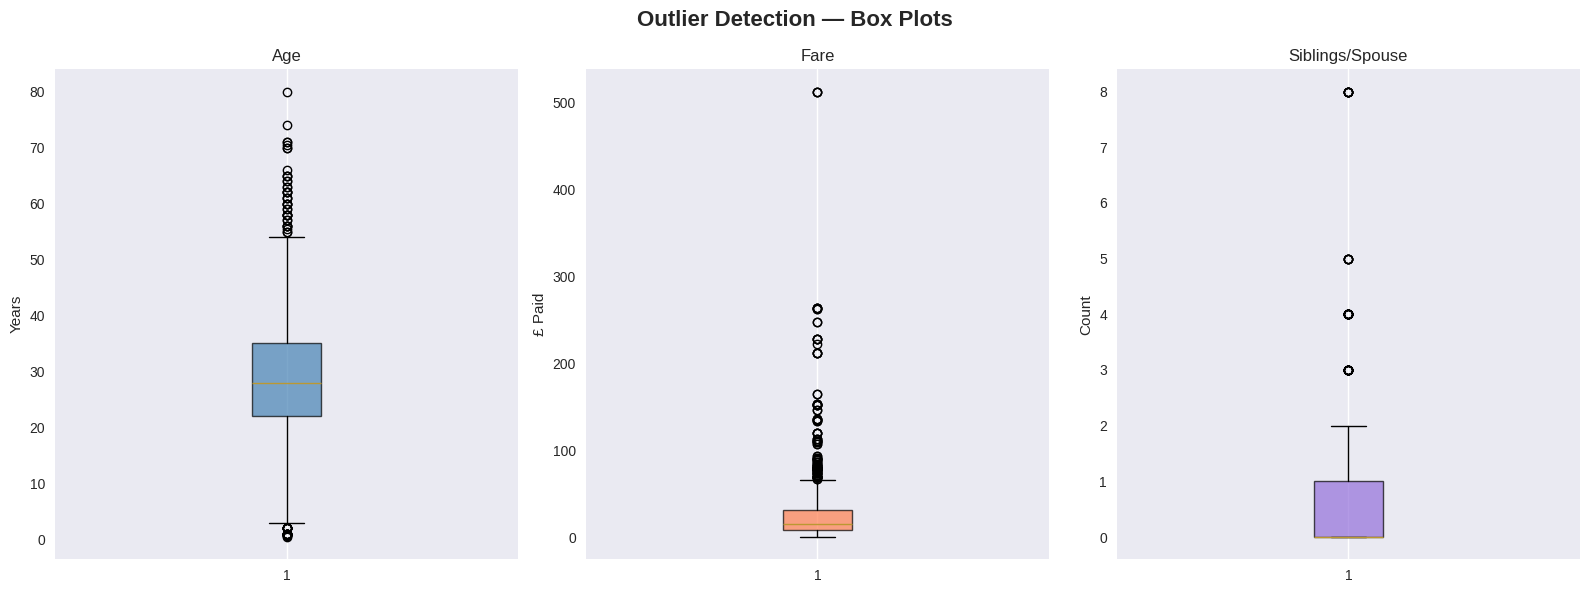

OUTLIER DETECTION — IQR METHOD

📊 Age:
   Q1: 22.0 | Q3: 35.0 | IQR: 13.0
   Lower bound: 2.5 | Upper bound: 54.5
   Outliers found: 66 passengers

📊 Fare:
   Q1: 7.9 | Q3: 31.0 | IQR: 23.1
   Lower bound: -26.7 | Upper bound: 65.6
   Outliers found: 116 passengers

📊 SibSp:
   Q1: 0.0 | Q3: 1.0 | IQR: 1.0
   Lower bound: -1.5 | Upper bound: 2.5
   Outliers found: 46 passengers


In [7]:
# ================================
# STEP 6 — OUTLIER DETECTION
# Outliers skew models — we need to find and understand them
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Outlier Detection — Box Plots",
             fontsize=16, fontweight="bold")

# Box plot — Age
axes[0].boxplot(df["Age"], patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[0].set_title("Age")
axes[0].set_ylabel("Years")
axes[0].grid(axis="y")

# Box plot — Fare
axes[1].boxplot(df["Fare"], patch_artist=True,
                boxprops=dict(facecolor="coral", alpha=0.7))
axes[1].set_title("Fare")
axes[1].set_ylabel("£ Paid")
axes[1].grid(axis="y")

# Box plot — SibSp
axes[2].boxplot(df["SibSp"], patch_artist=True,
                boxprops=dict(facecolor="mediumpurple", alpha=0.7))
axes[2].set_title("Siblings/Spouse")
axes[2].set_ylabel("Count")
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

# IQR Method — detect outliers mathematically
print("=" * 50)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 50)

for col in ["Age", "Fare", "SibSp"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n📊 {col}:")
    print(f"   Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}")
    print(f"   Lower bound: {lower:.1f} | Upper bound: {upper:.1f}")
    print(f"   Outliers found: {len(outliers)} passengers")

## Step 7 — Correlation Analysis
Finding which features actually predict survival.  
**Why this matters:** Correlation guides feature selection
the most critical step before building any ML model.

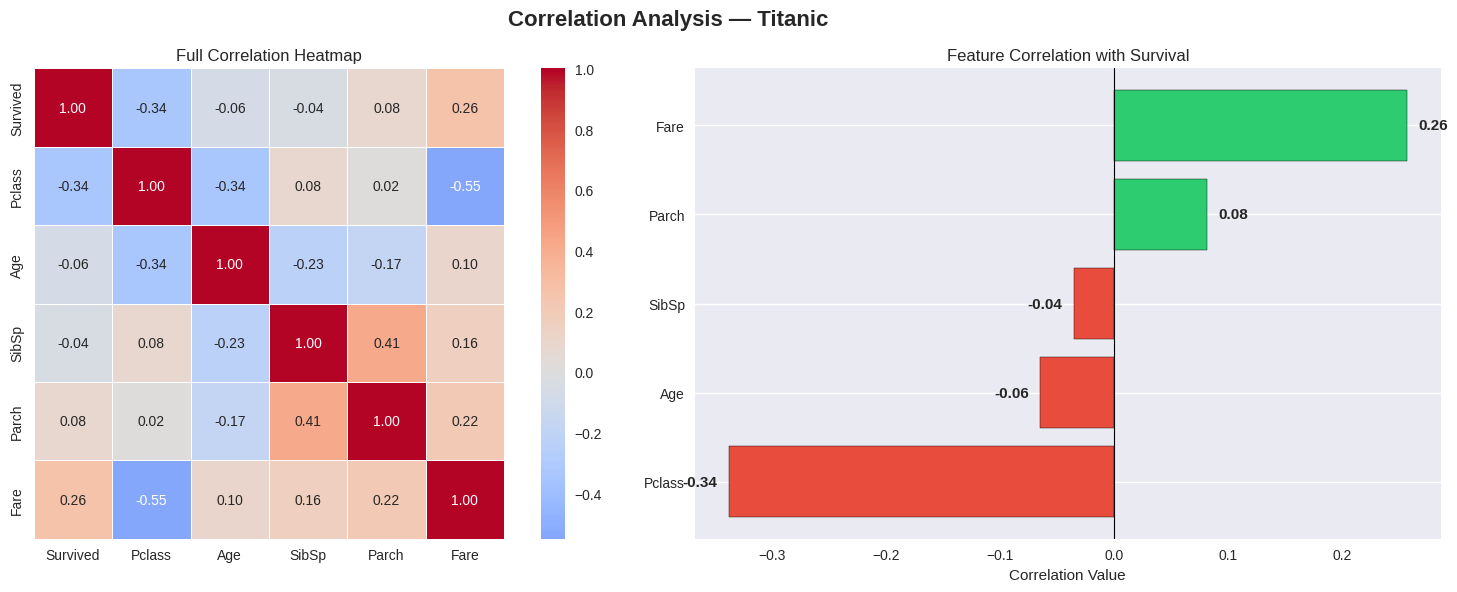

CORRELATION WITH SURVIVAL — INTERPRETATION

🟢 Fare: 0.26 (Strong positive)

⚪ Parch: 0.08 (Weak positive)

⚪ SibSp: -0.04 (Weak negative)

⚪ Age: -0.06 (Weak negative)

🔴 Pclass: -0.34 (Strong negative)


In [8]:
# ================================
# STEP 7 — CORRELATION ANALYSIS
# Which features actually predict survival?
# ================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation Analysis — Titanic",
             fontsize=16, fontweight="bold")

# Chart 1 — Full heatmap
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            ax=axes[0],
            linewidths=0.5,
            square=True)
axes[0].set_title("Full Correlation Heatmap")

# Chart 2 — Survival correlation only (cleaner view)
survival_corr = corr_matrix["Survived"].drop("Survived").sort_values()

colors = ["#E74C3C" if x < 0 else "#2ECC71" for x in survival_corr.values]
axes[1].barh(survival_corr.index,
             survival_corr.values,
             color=colors,
             edgecolor="black")

for i, val in enumerate(survival_corr.values):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01,
                 i, f"{val:.2f}",
                 va="center",
                 ha="left" if val >= 0 else "right",
                 fontsize=11, fontweight="bold")

axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Survival")
axes[1].set_xlabel("Correlation Value")
axes[1].grid(axis="x")

plt.tight_layout()
plt.show()

# Print interpretation
print("=" * 50)
print("CORRELATION WITH SURVIVAL — INTERPRETATION")
print("=" * 50)

for feature, corr in survival_corr.sort_values(ascending=False).items():
    if abs(corr) > 0.2:
        strength = "Strong"
        emoji = "🔴" if corr < 0 else "🟢"
    elif abs(corr) > 0.1:
        strength = "Moderate"
        emoji = "🟡"
    else:
        strength = "Weak"
        emoji = "⚪"

    direction = "positive" if corr > 0 else "negative"
    print(f"\n{emoji} {feature}: {corr:.2f} ({strength} {direction})")

   TITANIC EDA — FINAL INSIGHTS SUMMARY

📊 DATASET OVERVIEW
   • 891 passengers, 12 features
   • Only 38.4% survived — 549 people died

🔍 DATA QUALITY
   • Cabin dropped    — 77% missing, unusable
   • Age filled       — median 28 (20% was missing)
   • Embarked filled  — mode 'S' (only 2 missing)

👥 GENDER IMPACT
   • Female survival: 74.2%
   • Male survival:   18.9%
   • Women were 4x more likely to survive

🎫 CLASS IMPACT  
   • 1st class: 63.0% survived
   • 2nd class: 47.3% survived
   • 3rd class: 24.2% survived
   • Wealth literally bought survival

💰 FARE INSIGHTS
   • Mean fare: £32 but median only £14
   • 166 outliers — passengers paying up to £512
   • Skewed right — log transform needed for ML

🔗 STRONGEST PREDICTORS OF SURVIVAL
   • Pclass → -0.34 (strong negative)
   • Fare   → +0.26 (moderate positive)
   • Age    → -0.07 (barely matters)

💡 KEY INSIGHT
   The Titanic tragedy wasn't random.
   Gender and wealth were the two biggest
   factors that determined who lived

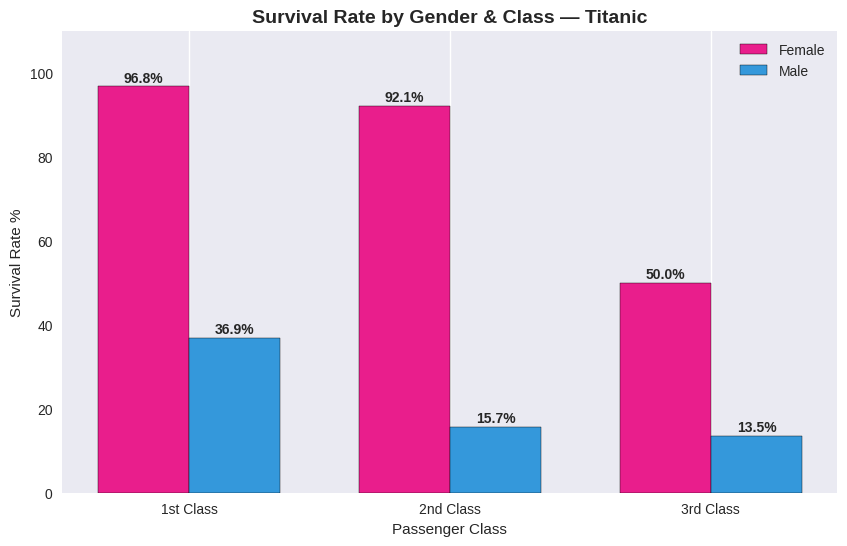

In [9]:
# ================================
# STEP 8 — KEY INSIGHTS SUMMARY
# The story the data tells us
# ================================

print("=" * 60)
print("   TITANIC EDA — FINAL INSIGHTS SUMMARY")
print("=" * 60)

print("""
📊 DATASET OVERVIEW
   • 891 passengers, 12 features
   • Only 38.4% survived — 549 people died

🔍 DATA QUALITY
   • Cabin dropped    — 77% missing, unusable
   • Age filled       — median 28 (20% was missing)
   • Embarked filled  — mode 'S' (only 2 missing)

👥 GENDER IMPACT
   • Female survival: 74.2%
   • Male survival:   18.9%
   • Women were 4x more likely to survive

🎫 CLASS IMPACT
   • 1st class: 63.0% survived
   • 2nd class: 47.3% survived
   • 3rd class: 24.2% survived
   • Wealth literally bought survival

💰 FARE INSIGHTS
   • Mean fare: £32 but median only £14
   • 166 outliers — passengers paying up to £512
   • Skewed right — log transform needed for ML

🔗 STRONGEST PREDICTORS OF SURVIVAL
   • Pclass → -0.34 (strong negative)
   • Fare   → +0.26 (moderate positive)
   • Age    → -0.07 (barely matters)

💡 KEY INSIGHT
   The Titanic tragedy wasn't random.
   Gender and wealth were the two biggest
   factors that determined who lived and
   who died that night.
""")

# Final chart — survival rate by gender AND class combined
pivot = df.pivot_table(values="Survived",
                       index="Pclass",
                       columns="Sex",
                       aggfunc="mean") * 100

plt.figure(figsize=(10, 6))
x = np.arange(3)
width = 0.35

bars1 = plt.bar(x - width/2, pivot["female"],
                width, label="Female",
                color="#E91E8C", edgecolor="black")
bars2 = plt.bar(x + width/2, pivot["male"],
                width, label="Male",
                color="#3498DB", edgecolor="black")

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{bar.get_height():.1f}%",
             ha="center", fontsize=10, fontweight="bold")

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{bar.get_height():.1f}%",
             ha="center", fontsize=10, fontweight="bold")

plt.title("Survival Rate by Gender & Class — Titanic",
          fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate %")
plt.xticks(x, ["1st Class", "2nd Class", "3rd Class"])
plt.legend()
plt.ylim(0, 110)
plt.grid(axis="y")
plt.show()